<a href="https://colab.research.google.com/github/krishnajaindev/netflix-analysis/blob/main/Netflix%20Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project Name**    - Netflix Analysis



##### **Project Type**    - EDA/Regression/Classification/Unsupervised
##### **Contribution**    - Team
##### **Team Member 1 - Krishna Jain
##### **Team Member 2 - Hitarth Singaria


# **Project Summary -**

Netflix is one of the world's largest streaming platforms, offering thousands of Movies and TV Shows to its subscribers across the globe. This project performs an **Exploratory Data Analysis (EDA)** on a dataset of **7,787 Netflix titles**, each described by 12 attributes such as `type`, `title`, `director`, `cast`, `country`, `date_added`, `release_year`, `rating`, `duration`, `genres`, and `description`.

The goal of this project is simple: **look at the raw data and turn it into a story**. We are not building a machine learning model here — EDA is about asking good questions and using tables, numbers, and charts to answer them.

We started by **understanding the dataset**: its shape (7,787 rows and 12 columns), its data types, and where it had missing values. We found that `director` (2,389 missing), `cast` (718 missing), `country` (507 missing), `date_added` (10 missing), and `rating` (7 missing) all had gaps, while there were **zero duplicate rows**. Rather than deleting this data, we filled missing categorical fields with a clear label (`"Not Specified"`) so we don't lose the row entirely, and filled the handful of missing ratings with the most common rating.

Next, in **Data Wrangling**, we prepared the dataset for analysis: we converted the text `date_added` column into a real date, and pulled out the `year_added` and `month_added` from it. Several columns like `genres`, `cast`, and `country` contain **multiple comma-separated values in a single cell** (e.g. one title can belong to 3 genres and be produced in 2 countries), so we "exploded" these columns wherever we needed to count individual genres, actors, or countries fairly.

In the **Visualization** section, we created 15 charts to explore the data from every angle: the split between Movies and TV Shows (about 69% Movies vs 31% TV Shows), the countries producing the most content (the United States and India lead by a wide margin), how many titles Netflix added every year (huge growth from 2016 to a peak in 2019), the most common content ratings (`TV-MA` and `TV-14` dominate, showing a catalog skewed toward mature audiences), the most frequent genres (International Movies, Dramas, and Comedies top the list), typical movie length (around 90-115 minutes), how many seasons TV shows usually run for (most only ever get **one season**), the most recurring directors and actors, seasonal patterns in when content is added (December and October are the busiest months), and how the Movie/TV Show mix differs by country (India's catalog is overwhelmingly movies, while the UK has a much more balanced mix).

Finally, we tied these findings back to a **business objective**: helping a content strategy team decide where to invest next — in more original TV Shows, in underrepresented regions, and in filling gaps in the ratings/genre mix — and we summarized this into clear, actionable recommendations in the conclusion.

This project is a good example of how raw, messy, real-world data (with missing values, multi-valued columns, and inconsistent formats) can be cleaned and explored using **Python, Pandas, Matplotlib, and Seaborn** to produce genuinely useful business insights.


# **GitHub Link -**

https://github.com/krishnajaindev/netflix-analysis

# **Problem Statement**


Netflix's content library has grown into thousands of Movies and TV Shows sourced from many countries, genres, directors, and cast members. With so much variety, it becomes hard for a content or business team to answer simple but important questions just by looking at spreadsheets:

- Does Netflix lean more towards Movies or TV Shows?
- Which countries and genres dominate the catalog, and which are underrepresented?
- Is the content mostly meant for mature audiences or for a general/family audience?
- How has the size of the catalog changed year over year?
- Are there patterns in *when* content gets added to the platform?

**The goal of this EDA is to explore the Netflix dataset and answer these questions using data, uncovering patterns and insights that can guide content strategy decisions.**

#### **Define Your Business Objective?**

The business objective is to help Netflix's **content acquisition and strategy team** understand the current shape of the catalog — its content type mix, genre and country strengths, audience-rating skew, and growth trend over time — so they can make **data-driven decisions** about:
1. Where to invest more (e.g., more Originals in a particular genre or region)
2. Which audience segments (by rating/age group) may be underserved
3. How to time major content releases throughout the year

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.


5. You have to create at least 20 logical & meaningful charts having important insights.

[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]







# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [142]:
# Import Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

%matplotlib inline

### Dataset Loading

In [143]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [144]:
# Load Dataset
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/NetFlix.csv')

### Dataset First View

In [145]:
# Dataset First Look
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,genres,description
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,14-Aug-20,2020,TV-MA,4,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s10,Movie,1920,Vikram Bhatt,"Rajneesh Duggal, Adah Sharma, Indraneil Sengup...",India,15-Dec-17,2008,TV-MA,143,"Horror Movies, International Movies, Thrillers",An architect and his wife move into a castle t...
2,s100,Movie,3 Heroines,Iman Brotoseno,"Reza Rahadian, Bunga Citra Lestari, Tara Basro...",Indonesia,5-Jan-19,2016,TV-PG,124,"Dramas, International Movies, Sports Movies",Three Indonesian women break records by becomi...
3,s1000,Movie,Blue Mountain State: The Rise of Thadland,Lev L. Spiro,"Alan Ritchson, Darin Brooks, James Cade, Rob R...",United States,1-Mar-16,2016,R,90,Comedies,New NFL star Thad buys his old teammates' belo...
4,s1001,TV Show,Blue Planet II,NaN,David Attenborough,United Kingdom,3-Dec-18,2017,TV-G,1,"British TV Shows, Docuseries, Science & Nature TV",This sequel to the award-winning nature series...


### Dataset Rows & Columns count

In [146]:
# Dataset Rows & Columns count
print("Number of Rows    :", df.shape[0])
print("Number of Columns :", df.shape[1])

Number of Rows    : 7787
Number of Columns : 12


### Dataset Information

In [147]:
# Dataset Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7787 entries, 0 to 7786
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       7787 non-null   object
 1   type          7787 non-null   object
 2   title         7787 non-null   object
 3   director      5398 non-null   object
 4   cast          7069 non-null   object
 5   country       7280 non-null   object
 6   date_added    7777 non-null   object
 7   release_year  7787 non-null   int64 
 8   rating        7780 non-null   object
 9   duration      7787 non-null   int64 
 10  genres        7787 non-null   object
 11  description   7787 non-null   object
dtypes: int64(2), object(10)
memory usage: 730.2+ KB


#### Duplicate Values

In [148]:
# Dataset Duplicate Value Count
duplicate_count = df.duplicated().sum()
print("Number of duplicate rows in the dataset:", duplicate_count)

Number of duplicate rows in the dataset: 0


#### Missing Values/Null Values

In [149]:
# Missing Values/Null Values Count
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2389
cast,718
country,507
date_added,10
release_year,0
rating,7
duration,0


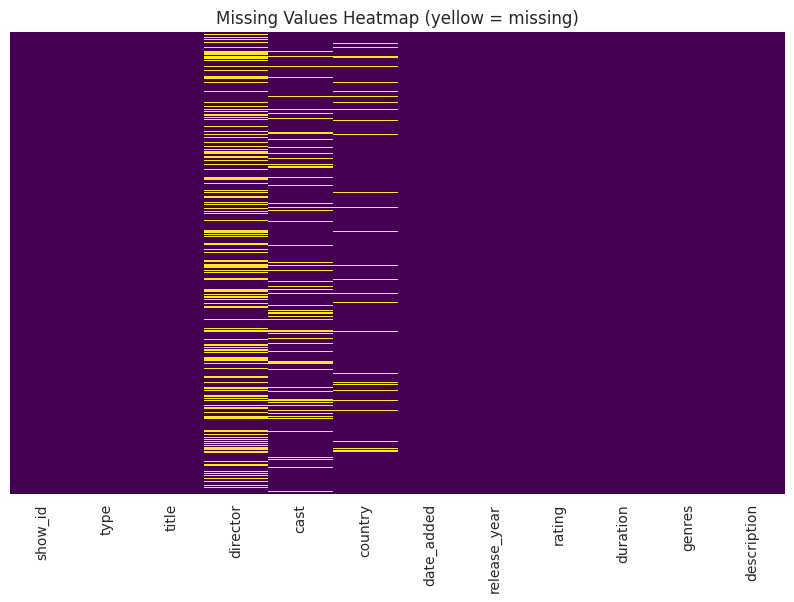

In [150]:
# Visualizing the missing values
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Missing Values Heatmap (yellow = missing)')
plt.show()

### What did you know about your dataset?

- The dataset has **7,787 rows** and **12 columns**.
- Each row represents one Netflix title, and the columns describe its `type` (Movie/TV Show), `title`, `director`, `cast`, `country`, `date_added` (to Netflix), `release_year`, `rating`, `duration`, `genres` and `description`.
- There are **no duplicate rows** in the dataset — every title appears only once.
- Several columns have missing values: `director` (2,389 missing), `cast` (718 missing), `country` (507 missing), `date_added` (10 missing), and `rating` (only 7 missing). This makes sense — many titles (especially documentaries or stand-up specials) genuinely don't have a listed "cast", and country info isn't always provided by the studio.
- The dataset contains **5,377 Movies** and **2,410 TV Shows** — so Movies make up roughly 69% of the catalog.
- `release_year` ranges from as far back as **1925** all the way to **2021**, but as we'll see, most content is from the last decade.
- Columns like `genres`, `cast`, and `country` are **multi-valued** — a single cell can contain several comma-separated values (e.g. `"Dramas, International Movies, Romantic Movies"`). We need to keep this in mind during analysis so we don't undercount things.

## ***2. Understanding Your Variables***

In [151]:
# Dataset Columns
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'genres', 'description'],
      dtype='object')

In [152]:
# Dataset Describe
df.describe()

,release_year,duration
count,7787.000000,7787.000000
mean,2013.932580,69.122769
std,8.757395,50.950743
min,1925.000000,1.000000
25%,2013.000000,2.000000
50%,2017.000000,88.000000
75%,2018.000000,106.000000
max,2021.000000,312.000000


### Variables Description

| Column | Description |
|---|---|
| `show_id` | A unique ID assigned to every title |
| `type` | Whether the title is a `Movie` or a `TV Show` |
| `title` | The name of the Movie/TV Show |
| `director` | The director(s) of the title (many are missing, especially for TV Shows) |
| `cast` | The main actors/actresses featured |
| `country` | The country (or countries) where the title was produced |
| `date_added` | The date the title was added to Netflix |
| `release_year` | The year the title was originally released |
| `rating` | The content/age rating (e.g. `TV-MA`, `PG-13`, `TV-Y`) |
| `duration` | For Movies: length in **minutes**. For TV Shows: number of **seasons** |
| `genres` | One or more genres/categories the title belongs to |
| `description` | A short summary of the plot |

### Check Unique Values for each variable.

In [153]:
# Check Unique Values for each variable.
for column in df.columns:
    print(f"{column} -> {df[column].nunique()} unique values")

show_id -> 7787 unique values
type -> 2 unique values
title -> 7787 unique values
director -> 4049 unique values
cast -> 6831 unique values
country -> 681 unique values
date_added -> 1565 unique values
release_year -> 73 unique values
rating -> 14 unique values
duration -> 206 unique values
genres -> 492 unique values
description -> 7769 unique values


## 3. ***Data Wrangling***

### Data Wrangling Code

In [154]:
# Write your code to make your dataset analysis ready.

# We work on a COPY of the original data so df stays untouched (good practice!)
netflix = df.copy()


netflix['director'] = netflix['director'].fillna('Not Specified')
netflix['cast']      = netflix['cast'].fillna('Not Specified')
netflix['country']   = netflix['country'].fillna('Not Specified')

# 2) Only 7 rows are missing a 'rating' -- too few to justify dropping data,
#    so we fill them with the MODE (the most frequently occurring rating).
netflix['rating'] = netflix['rating'].fillna(netflix['rating'].mode()[0])

# 3) Convert 'date_added' from plain text (e.g. "14-Aug-20") into an actual date.
#    errors='coerce' turns any unparseable dates into NaT (missing) instead of crashing.
netflix['date_added'] = pd.to_datetime(netflix['date_added'].str.strip(),
                                        format='%d-%b-%y', errors='coerce')

# 4) Now that it's a real date, we can easily pull out the year and month added.
netflix['year_added']  = netflix['date_added'].dt.year
netflix['month_added'] = netflix['date_added'].dt.month_name()

# 5) 'genres' can hold multiple values, e.g. "Dramas, Comedies".
#    We create a 'primary_genre' column using just the FIRST genre listed,
#    which is useful whenever we want one clean genre label per title.
netflix['primary_genre'] = netflix['genres'].apply(lambda x: x.split(',')[0].strip())

# Quick sanity check: confirm the missing values are handled
print("Missing values remaining in cleaned columns:")
print(netflix[['director', 'cast', 'country', 'rating']].isnull().sum())
print()

netflix.head()

Missing values remaining in cleaned columns:
director    0
cast        0
country     0
rating      0
dtype: int64



,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,genres,description,year_added,month_added,primary_genre
0,s1,TV Show,3%,Not Specified,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,2020-08-14,2020,TV-MA,4,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...,2020.0,August,International TV Shows
1,s10,Movie,1920,Vikram Bhatt,"Rajneesh Duggal, Adah Sharma, Indraneil Sengup...",India,2017-12-15,2008,TV-MA,143,"Horror Movies, International Movies, Thrillers",An architect and his wife move into a castle t...,2017.0,December,Horror Movies
2,s100,Movie,3 Heroines,Iman Brotoseno,"Reza Rahadian, Bunga Citra Lestari, Tara Basro...",Indonesia,2019-01-05,2016,TV-PG,124,"Dramas, International Movies, Sports Movies",Three Indonesian women break records by becomi...,2019.0,January,Dramas
3,s1000,Movie,Blue Mountain State: The Rise of Thadland,Lev L. Spiro,"Alan Ritchson, Darin Brooks, James Cade, Rob R...",United States,2016-03-01,2016,R,90,Comedies,New NFL star Thad buys his old teammates' belo...,2016.0,March,Comedies
4,s1001,TV Show,Blue Planet II,Not Specified,David Attenborough,United Kingdom,2018-12-03,2017,TV-G,1,"British TV Shows, Docuseries, Science & Nature TV",This sequel to the award-winning nature series...,2018.0,December,British TV Shows


### What all manipulations have you done and insights you found?

**Manipulations performed:**
1. Filled missing `director`, `cast`, and `country` values with `"Not Specified"` instead of deleting rows — this preserves all 7,787 records for analysis.
2. Filled the 7 missing `rating` values with the mode (most common rating) since it's too small a number to warrant dropping data.
3. Converted `date_added` from a text string into an actual datetime column, which let us extract a clean `year_added` and `month_added` for time-based analysis.
4. Created a `primary_genre` column by taking the first genre listed for each title, since many titles list 2-3 genres and we needed one representative genre per row for some charts.
5. For charts that count countries, genres, or actors fairly, we **"exploded"** those multi-valued columns (split on comma) so a title with 3 genres contributes to the count of all 3 genres, not just one.

**Key insight from wrangling:** the amount of missing data itself tells a story — `director` is missing for about 30% of titles, largely because **TV Shows often don't credit a single director** the way Movies do. This is a data-quality nuance to keep in mind rather than a random error.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

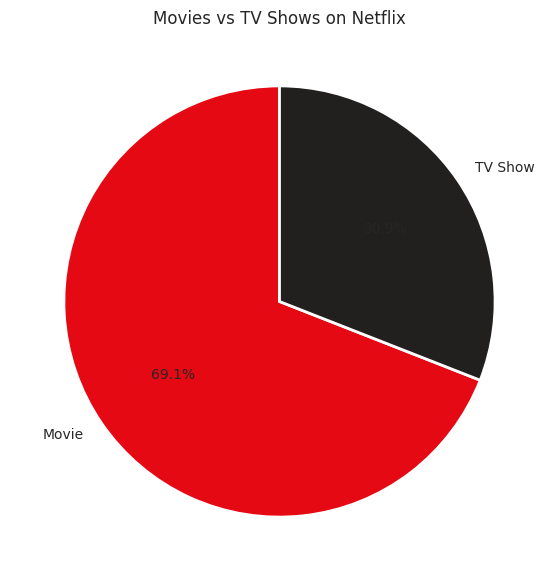

In [155]:
# Chart - 1 visualization code
plt.figure(figsize=(7, 7))
type_counts = netflix['type'].value_counts()
plt.pie(type_counts, labels=type_counts.index, autopct='%1.1f%%',
        colors=['#E50914', '#221f1f'], startangle=90,
        wedgeprops={'edgecolor': 'white', 'linewidth': 2})
plt.title('Movies vs TV Shows on Netflix')
plt.show()

##### 1. Why did you pick the specific chart?

A pie chart is a great fit here because `type` has only **two categories** (Movie, TV Show), and we want to show the **proportion** each one makes up of the whole catalog at a glance.





##### 2. What is/are the insight(s) found from the chart?

**Movies make up about 69% of the catalog (5,377 titles)** while **TV Shows make up about 31% (2,410 titles)**. Netflix's library is clearly Movie-heavy.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This is a **positive, actionable insight**: TV Shows are known in the streaming industry to drive longer subscriber engagement (people keep coming back for the next episode/season), so a content team could use this finding to justify **investing more in Original TV Show production** to balance the catalog and improve retention. There's no direct "negative growth" signal here — it's simply a gap/opportunity.

#### Chart - 2

In [156]:
# Chart - 2 visualization code

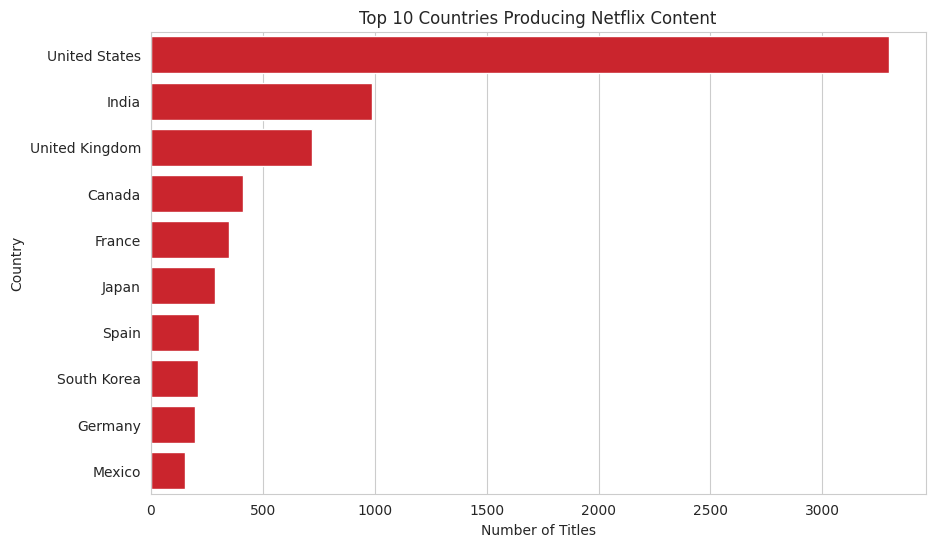

In [157]:
country_series = netflix['country'].str.split(', ').explode()
top_countries = country_series[country_series != 'Not Specified'].value_counts().head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_countries.values, y=top_countries.index, color='#E50914')
plt.title('Top 10 Countries Producing Netflix Content')
plt.xlabel('Number of Titles')
plt.ylabel('Country')
plt.show()

##### 1. Why did you pick the specific chart?

A horizontal bar chart works well for **ranking categories** (countries) by a count — it's easy to compare bar lengths and read long country names on the y-axis.Answer Here.

##### 2. What is/are the insight(s) found from the chart?

The **United States (3,296 credits)** and **India (990 credits)** dominate content production by a huge margin, followed by the **United Kingdom (722)**, **Canada (412)**, and **France (349)**. Many other countries appear far less frequently.Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive impact:** this highlights a **concentration risk** — the catalog leans heavily on just two markets. A regional expansion strategy (investing in local-language Originals in underrepresented but high-growth regions) could help Netflix diversify its content base and attract new international subscribers. Over-reliance on two markets isn't necessarily "negative growth" today, but it is a strategic gap worth addressing.

#### Chart - 3

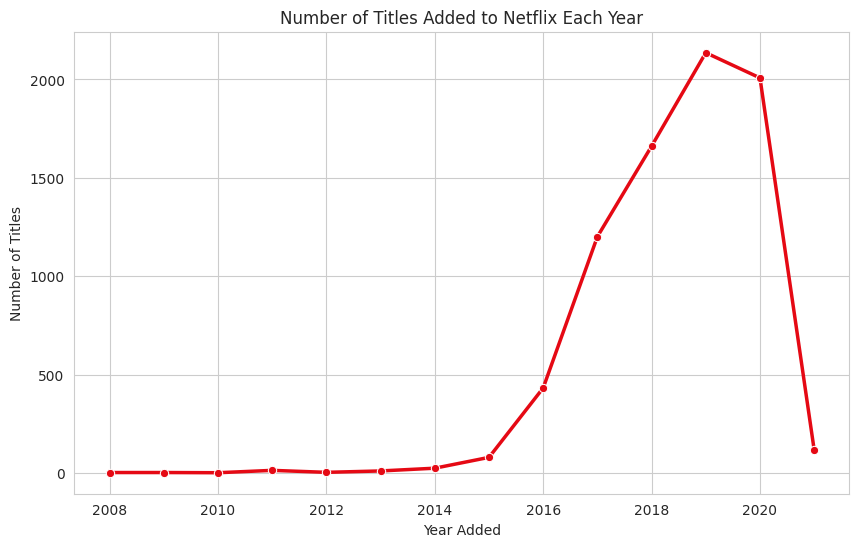

In [158]:
# Chart - 3 visualization code
yearly_additions = netflix['year_added'].value_counts().sort_index()

plt.figure(figsize=(10, 6))
sns.lineplot(x=yearly_additions.index, y=yearly_additions.values,
             marker='o', color='#E50914', linewidth=2.5)
plt.title('Number of Titles Added to Netflix Each Year')
plt.xlabel('Year Added')
plt.ylabel('Number of Titles')
plt.show()

##### 1. Why did you pick the specific chart?

A line chart is the standard choice for showing a trend **over time** — here, how the number of titles added per year changed.

##### 2. What is/are the insight(s) found from the chart?

Content additions were minimal before 2015, then **exploded from 432 titles in 2016 to a peak of 2,136 in 2019** — a nearly 5x jump in just 3 years. 2020 saw a slight dip (2,008 titles), and 2021 shows very few titles simply because the dataset only covers early January of that year.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive impact:** the huge 2016-2019 growth phase shows Netflix's aggressive content-acquisition strategy paid off in catalog size. The **2020 dip is a mild caution flag** — it could reflect real-world production slowdowns (e.g., pandemic-related delays), which a strategy team should account for when planning future content pipelines to avoid a repeat slowdown.

#### Chart - 4

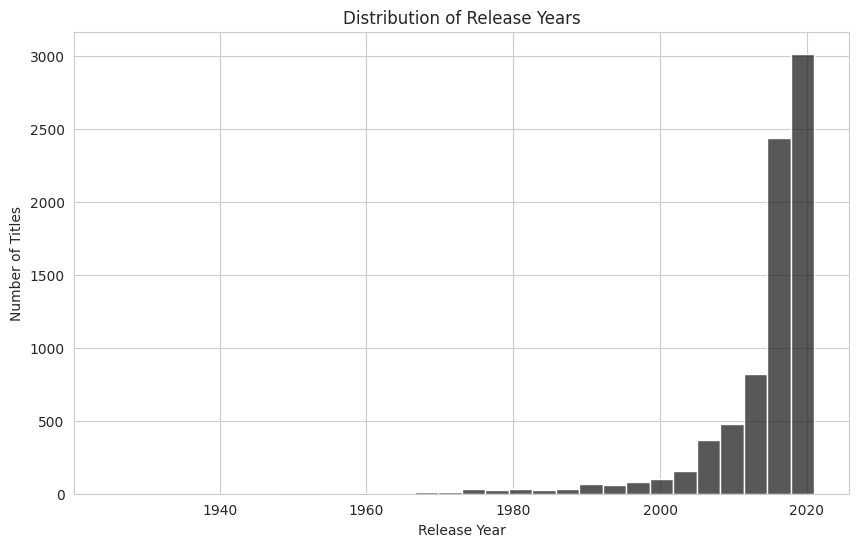

In [159]:
# Chart - 4 visualization code
plt.figure(figsize=(10, 6))
sns.histplot(netflix['release_year'], bins=30, color='#221f1f')
plt.title('Distribution of Release Years')
plt.xlabel('Release Year')
plt.ylabel('Number of Titles')
plt.show()

##### 1. Why did you pick the specific chart?

A histogram is ideal for showing how a **numeric variable** (`release_year`) is distributed/spread out across its range.

##### 2. What is/are the insight(s) found from the chart?

The distribution is heavily **right-skewed towards recent years** — the vast majority of titles were released between **2010 and 2020**, with 2018 alone contributing 1,121 titles. Very few titles date back before 2000, with the oldest from 1925.*Answer* Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive:** this confirms Netflix's catalog is modern and relevant, which appeals to subscribers looking for recent content. However, the near-absence of classic/older titles could be a **missed opportunity** to attract niche audiences (film enthusiasts, nostalgia-driven viewers) who value a deeper back-catalog — a small but real content gap.

#### Chart - 5

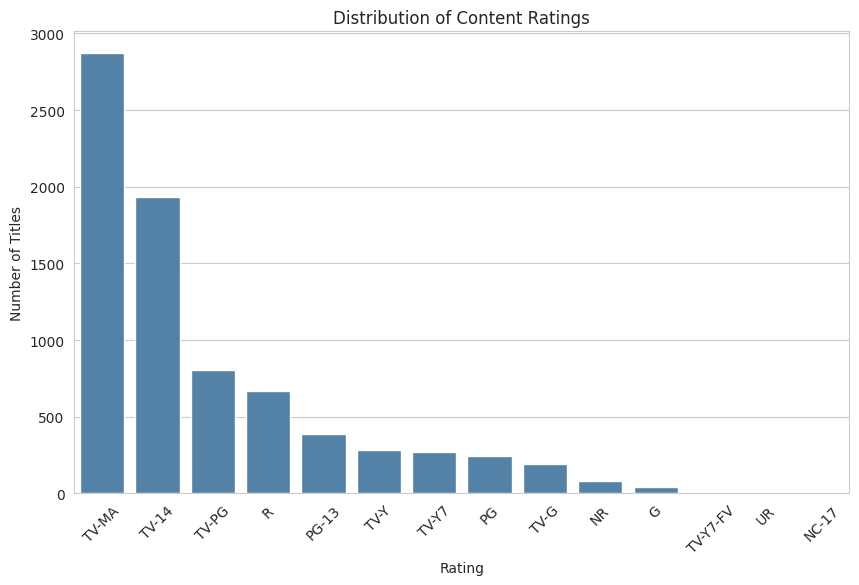

In [160]:
# Chart - 5 visualization code
plt.figure(figsize=(10, 6))
order = netflix['rating'].value_counts().index
sns.countplot(x='rating', data=netflix, order=order, color='steelblue')
plt.title('Distribution of Content Ratings')
plt.xlabel('Rating')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45)
plt.show()

##### 1. Why did you pick the specific chart?

A count plot (bar chart of frequencies) is the natural choice for a **categorical column** like `rating`, letting us instantly see which categories are most/least common.

##### 2. What is/are the insight(s) found from the chart?

**`TV-MA` (mature audience, 2,863 titles)** and **`TV-14` (1,931 titles)** are by far the most common ratings — together they make up over **60% of the entire catalog**. Content aimed at young children (`TV-Y`: 280, `TV-Y7`: 271, `G`: 39) is comparatively rare.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This cuts both ways: it's **positive** if Netflix's core strategy is targeting adult/teen viewers (its largest paying demographic). But it also reveals a **potential negative growth risk**: a comparatively thin kids/family catalog could push family-plan subscribers towards competitors with stronger children's content libraries, so this segment may need dedicated investment.

#### Chart - 6

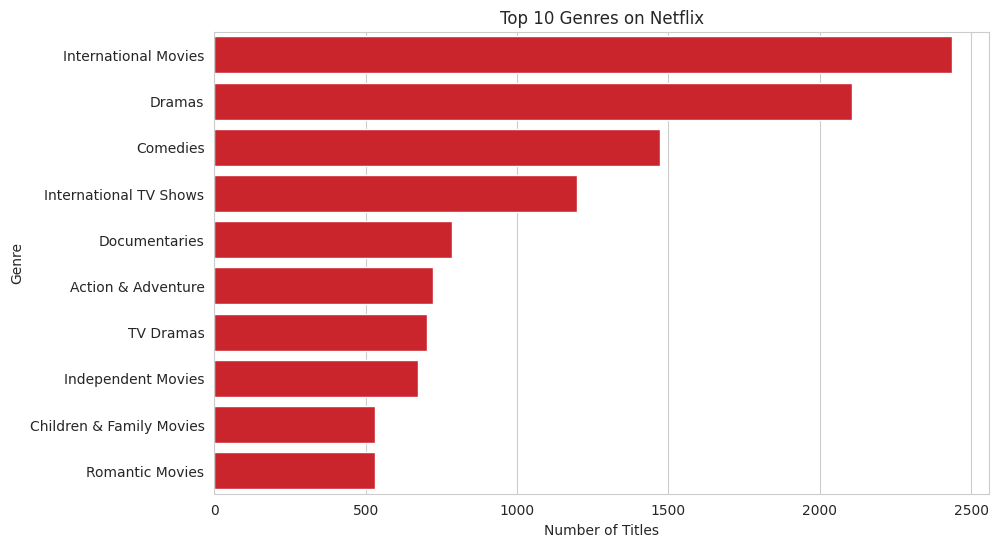

In [161]:
# Chart - 6 visualization code
genre_series = netflix['genres'].str.split(', ').explode()
top_genres = genre_series.value_counts().head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_genres.values, y=top_genres.index, color='#E50914')
plt.title('Top 10 Genres on Netflix')
plt.xlabel('Number of Titles')
plt.ylabel('Genre')
plt.show()

##### 1. Why did you pick the specific chart?

Same reasoning as the countries chart — a horizontal bar chart ranks multi-valued categorical data (genres) clearly, and reads well with longer genre names.

##### 2. What is/are the insight(s) found from the chart?

**International Movies (2,437)**, **Dramas (2,106)**, and **Comedies (1,471)** are the three most common genres, followed by **International TV Shows (1,199)** and **Documentaries (786)**. Drama and Comedy clearly anchor the catalog.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive impact:** Dramas and Comedies are broadly popular genres, so this mix likely serves a wide audience well. It also confirms the "International" tag is doing a lot of work across the catalog — reinforcing the earlier finding that global content is a major pillar of Netflix's strategy.

#### Chart - 7

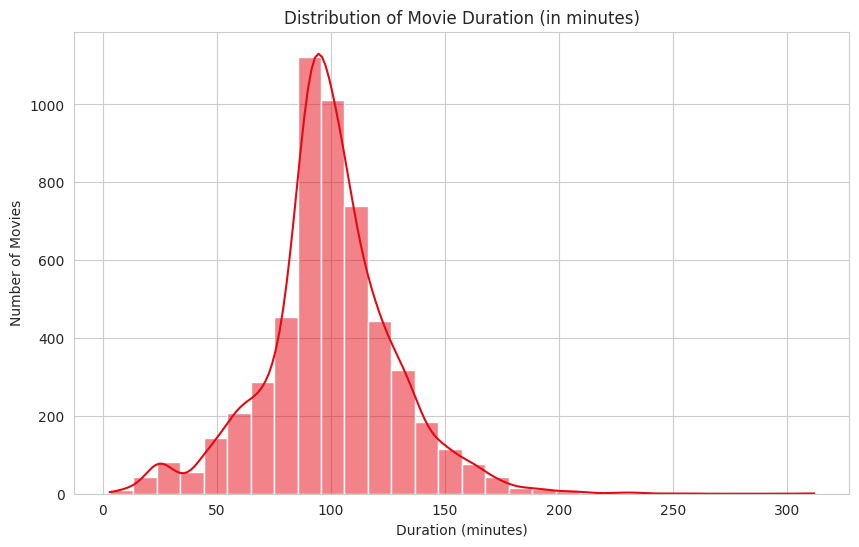

In [162]:
# Chart - 7 visualization code
movies = netflix[netflix['type'] == 'Movie']

plt.figure(figsize=(10, 6))
sns.histplot(movies['duration'], bins=30, color='#E50914', kde=True)
plt.title('Distribution of Movie Duration (in minutes)')
plt.xlabel('Duration (minutes)')
plt.ylabel('Number of Movies')
plt.show()

##### 1. Why did you pick the specific chart?

A histogram (with a smoothed density curve) is the best way to see the typical range and shape of a continuous numeric variable like movie length.

##### 2. What is/are the insight(s) found from the chart?

Movie durations follow a fairly normal, **bell-shaped distribution centered around 90-115 minutes** (mean ≈ 99 minutes), matching standard feature-film length. A small number of outlier movies run much longer (up to 312 minutes).

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive/neutral:** durations align with industry norms, so there's no red flag here. This is more of a **confirmatory insight** — it validates that the catalog's movies are "normal" theatrical/streaming-length films rather than an unusual mix of shorts or extra-long content.

#### Chart - 8

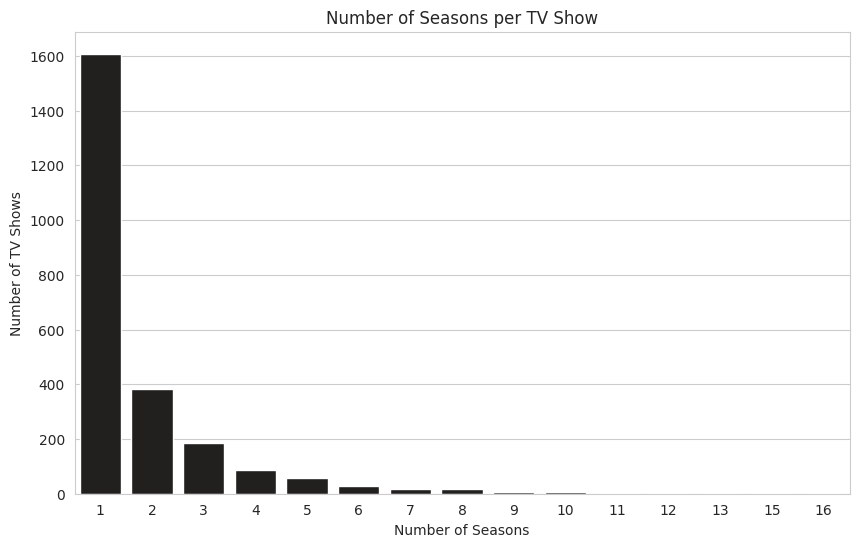

In [163]:
# Chart - 8 visualization code
tv_shows = netflix[netflix['type'] == 'TV Show']

plt.figure(figsize=(10, 6))
sns.countplot(x='duration', data=tv_shows, color='#221f1f')
plt.title('Number of Seasons per TV Show')
plt.xlabel('Number of Seasons')
plt.ylabel('Number of TV Shows')
plt.show()

##### 1. Why did you pick the specific chart?

`duration` for TV Shows is a **whole number** (season count) with relatively

1.   List item
2.   List item

few distinct values, so a count plot clearly shows how many shows fall into each season-count bucket.

##### 2. What is/are the insight(s) found from the chart?

The vast majority of TV Shows have **just 1 season** (median = 1, mean ≈ 1.8), with the number of shows dropping off sharply as season count increases. Very few shows reach 5+ seasons.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This is a **potential negative-growth signal**: a catalog full of single-season shows suggests either many shows aren't being renewed, or Netflix licenses only the newest season of shows it doesn't own. Since **multi-season shows are proven to boost long-term retention** (viewers stay subscribed to finish a series), this points to a real opportunity — greenlighting more seasons of already-popular shows rather than only acquiring new single-season titles.

#### Chart - 9

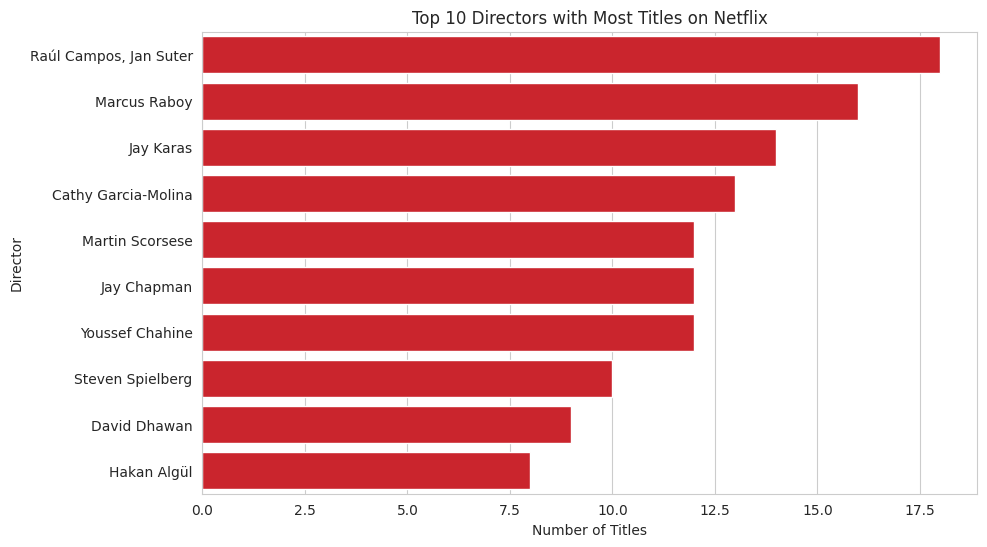

In [164]:
# Chart - 9 visualization code

top_directors = netflix[netflix['director'] != 'Not Specified']['director'].value_counts().head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_directors.values, y=top_directors.index, color='#E50914')
plt.title('Top 10 Directors with Most Titles on Netflix')
plt.xlabel('Number of Titles')
plt.ylabel('Director')
plt.show()

##### 1. Why did you pick the specific chart?

A ranked horizontal bar chart is the clearest way to compare a "top N" list of categories (directors) by count.

##### 2. What is/are the insight(s) found from the chart?

**Raúl Campos & Jan Suter** (a directing duo, largely of comedy specials) lead with **18 titles**, followed by **Marcus Raboy (16)**, **Jay Karas (14)**, and well-known names like **Martin Scorsese (12)** and **Steven Spielberg (10)** also appear. No single director dominates — the catalog is sourced from a wide, diverse pool of creators.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive impact:** the recurring names (especially comedy-special directors) suggest **successful, repeatable content partnerships** worth continuing or expanding. It's a healthy sign that no one director is a single point of failure for the catalog.

#### Chart - 10

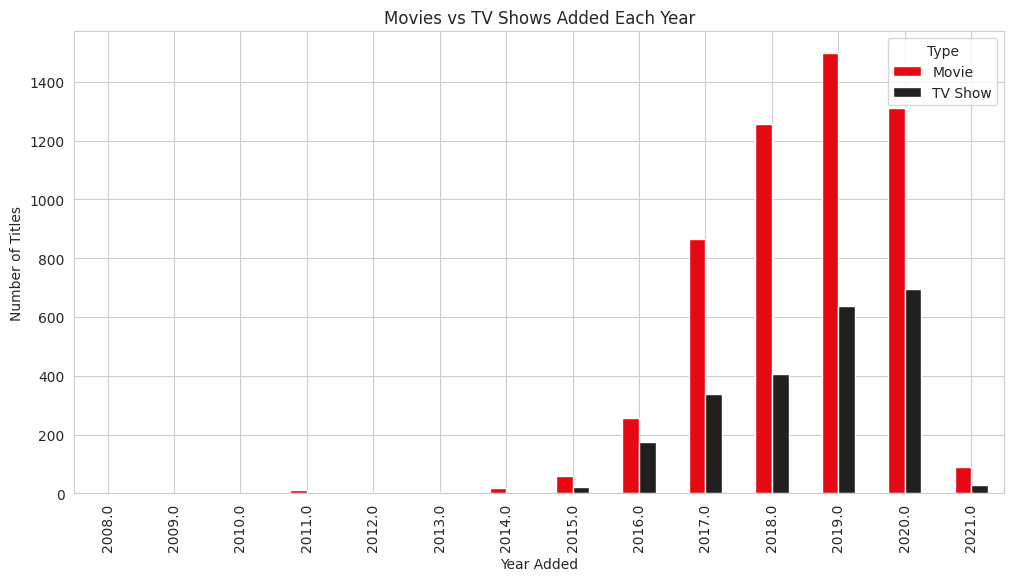

In [165]:
# Chart - 10 visualization code

yearly_type = netflix.groupby(['year_added', 'type']).size().unstack()

plt.figure(figsize=(12, 6))
ax = plt.gca()
yearly_type.plot(kind='bar', color=['#E50914', '#221f1f'], ax=ax)
plt.title('Movies vs TV Shows Added Each Year')
plt.xlabel('Year Added')
plt.ylabel('Number of Titles')
plt.legend(title='Type')
plt.show()

##### 1. Why did you pick the specific chart?

A grouped/side-by-side bar chart is perfect for comparing **two categories (Movie vs TV Show) across multiple time periods** at once.

##### 2. What is/are the insight(s) found from the chart?

Both content types grew every year through 2019, but the **TV Show share has been steadily rising**: TV Shows made up about 24% of new titles in 2018, rising to 30% in 2019 and about 35% in 2020 — Netflix has clearly been shifting investment towards TV Shows in recent years.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive impact:** this trend aligns perfectly with the earlier Chart 1 recommendation — Netflix already appears to be increasing its TV Show investment year over year, and this data supports **continuing that momentum** since TV shows tend to improve subscriber retention.

#### Chart - 11

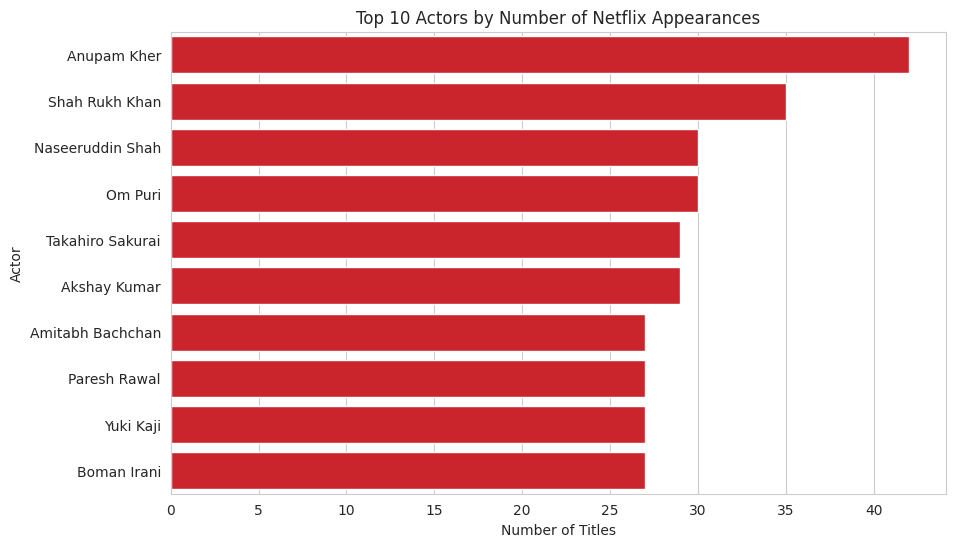

In [166]:
# Chart - 11 visualization code

# 'cast' can list many actors per title, so we split and count each one individually
cast_series = netflix[netflix['cast'] != 'Not Specified']['cast'].str.split(', ').explode()
top_actors = cast_series.value_counts().head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_actors.values, y=top_actors.index, color='#E50914')
plt.title('Top 10 Actors by Number of Netflix Appearances')
plt.xlabel('Number of Titles')
plt.ylabel('Actor')
plt.show()

##### 1. Why did you pick the specific chart?

Again, a ranked horizontal bar chart is the clearest way to show a "top N" ranking — here, of actors by appearance count.

##### 2. What is/are the insight(s) found from the chart?

**Anupam Kher (42 titles)**, **Shah Rukh Khan (35)**, **Om Puri (30)**, and **Naseeruddin Shah (30)** top the list — the top actors list is dominated by **Bollywood/Indian actors**, reflecting the strong presence of Indian cinema (seen earlier in Chart 2) in the catalog.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive impact:** this confirms India is not just a source of *volume* but of **recurring, bankable talent** — useful information if Netflix wants to build region-specific marketing campaigns or negotiate multi-title deals with popular actors.

#### Chart - 12

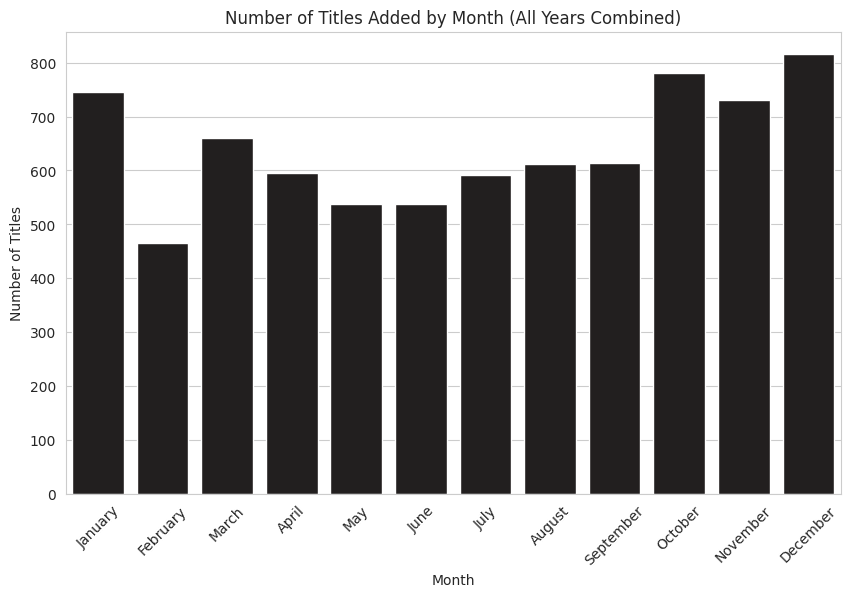

In [167]:
# Chart - 12 visualization code

month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']
monthly_counts = netflix['month_added'].value_counts().reindex(month_order)

plt.figure(figsize=(10, 6))
sns.barplot(x=monthly_counts.index, y=monthly_counts.values, color='#221f1f')
plt.title('Number of Titles Added by Month (All Years Combined)')
plt.xlabel('Month')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45)
plt.show()

##### 1. Why did you pick the specific chart?

A bar chart ordered by calendar month (not by size) is the right choice here, since we specifically want to see the **seasonal pattern** across the year rather than just a ranking.

##### 2. What is/are the insight(s) found from the chart?

**December (817 titles)** and **October (780 titles)** are the busiest months for adding new content, while **February (466 titles)** is the quietest. This suggests a deliberate release pattern around the **holiday season and fall (possibly tied to Halloween-themed content in October)**.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive impact:** this is directly actionable — a marketing team can plan **major promotional campaigns around the October/December content pushes**, and could consider adding more content in traditionally quieter months (like February) to keep subscriber engagement more consistent throughout the year.

#### Chart - 13

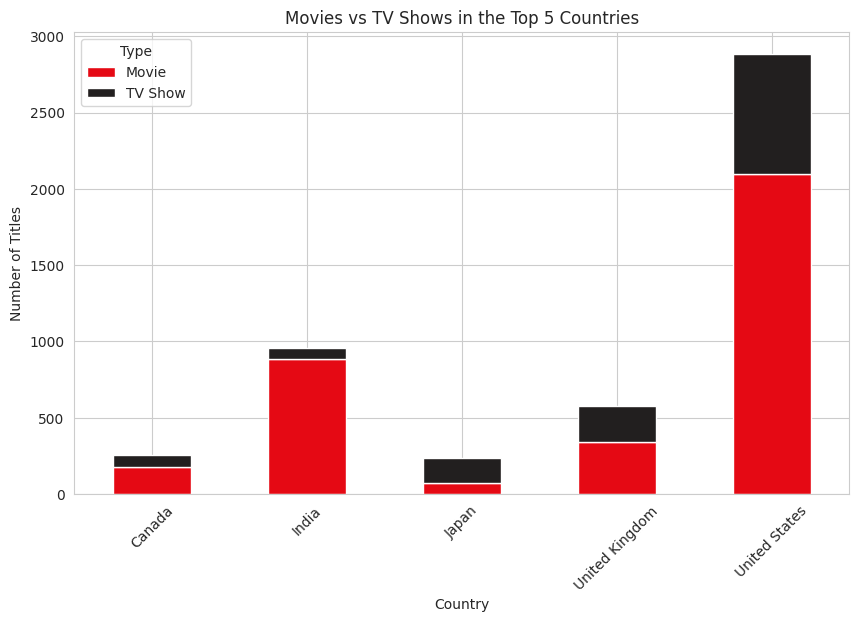

In [168]:
# Chart - 13 visualization code

# Take the top 5 countries (by primary/first-listed country) and compare their Movie/TV Show mix
netflix['primary_country'] = netflix['country'].apply(lambda x: x.split(',')[0].strip())
top5_countries = netflix[netflix['primary_country'] != 'Not Specified']['primary_country'].value_counts().head(5).index

subset = netflix[netflix['primary_country'].isin(top5_countries)]
country_type = subset.groupby(['primary_country', 'type']).size().unstack()

plt.figure(figsize=(10, 6))
ax = plt.gca()
country_type.plot(kind='bar', stacked=True, color=['#E50914', '#221f1f'], ax=ax)
plt.title('Movies vs TV Shows in the Top 5 Countries')
plt.xlabel('Country')
plt.ylabel('Number of Titles')
plt.legend(title='Type')
plt.xticks(rotation=45)
plt.show()

##### 1. Why did you pick the specific chart?

A **stacked bar chart** is ideal for comparing how a total (titles per country) is split between two sub-categories (Movie vs TV Show) side-by-side across several countries.

##### 2. What is/are the insight(s) found from the chart?

**India's catalog is overwhelmingly Movies** (883 Movies vs only 73 TV Shows — TV Shows are just ~8% of India's content), while the **United Kingdom has a much more balanced mix** (341 Movies vs 236 TV Shows — TV Shows make up ~41%). The US sits in between, with TV Shows at about 27% of its catalog.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive impact:** this reveals a clear regional content gap — **India's TV Show catalog looks underdeveloped** relative to its huge Movie presence and audience size. Investing in Indian-language Original series could be a high-potential growth opportunity, following the UK's more balanced model.

#### Chart - 14 - Correlation Heatmap

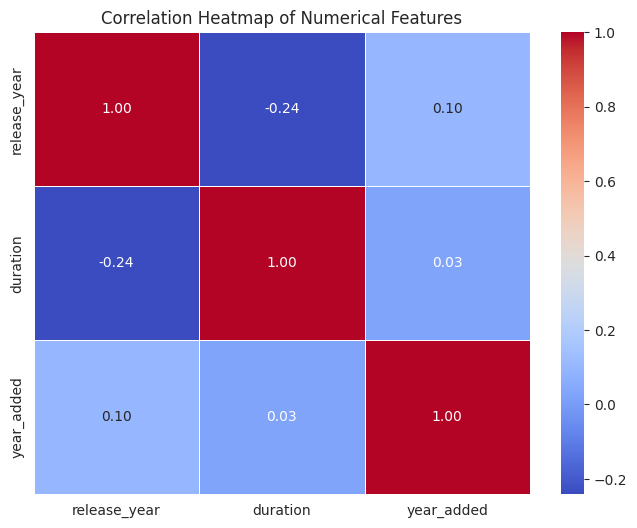

In [169]:
# Correlation Heatmap visualization code

numeric_df = netflix[['release_year', 'duration', 'year_added']]

plt.figure(figsize=(8, 6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

##### 1. Why did you pick the specific chart?

A correlation heatmap is the standard way to quickly check whether any of our **numeric columns move together** (correlate) with each other.

##### 2. What is/are the insight(s) found from the chart?

The correlations here are **weak overall** — `release_year` and `duration` show a mild negative correlation (about -0.24), hinting that newer titles trend slightly shorter, while `year_added` barely correlates with either. This isn't surprising, since most of this dataset's meaningful information (genre, cast, country) is categorical/text, not numeric.

#### Chart - 15 - Pair Plot

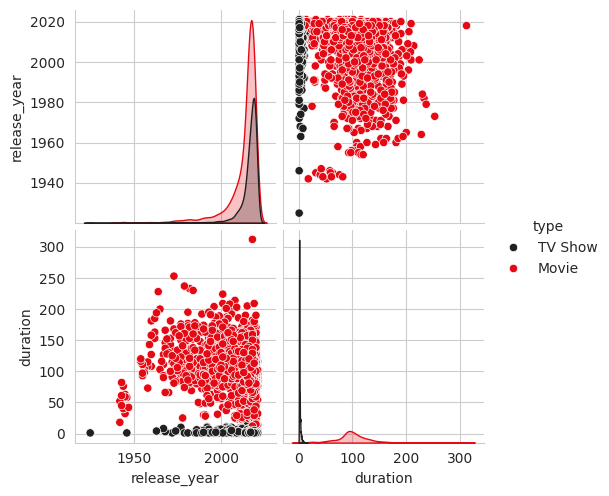

In [170]:
# Pair Plot visualization code

pairplot_data = netflix[['release_year', 'duration', 'type']].dropna()
sns.pairplot(pairplot_data, hue='type', palette={'Movie': '#E50914', 'TV Show': '#221f1f'})
plt.show()

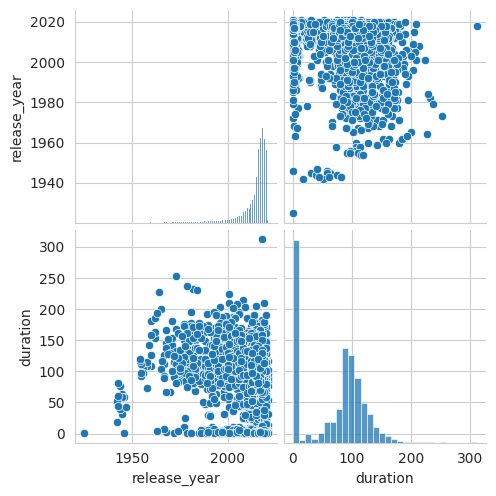

In [171]:
sns.pairplot(df)

##### 1. Why did you pick the specific chart?

A pair plot lets us see **every numeric column plotted against every other one, split by category (`type`)**, all in a single view — useful as a final "everything at once" check before wrapping up the numeric analysis.

##### 2. What is/are the insight(s) found from the chart?

The pair plot visually confirms what we already found: **Movie durations (minutes) and TV Show durations (seasons) occupy completely different, non-overlapping scales**, and there's no strong linear pattern between `release_year` and `duration` for either type — consistent with the weak correlations from the heatmap.

## **5. Solution to Business Objective**

#### What do you suggest the client to achieve Business Objective ?
Explain Briefly.

Based on the analysis above, here are concrete, data-backed recommendations for Netflix's content strategy team:

1. **Grow the TV Show catalog further.** TV Shows are only ~31% of the catalog today, but their share of *new additions* has been rising every year (24% → 30% → 35% from 2018-2020). TV shows drive longer engagement, so this momentum should be sustained and accelerated.

2. **Invest in renewing shows for multiple seasons**, not just acquiring new single-season shows — most TV Shows in the catalog (median) have only 1 season, which limits long-term retention value per title.

3. **Diversify beyond the US and India.** These two countries dominate the catalog; investing in Original content from other high-growth regions (following the success already seen with UK, Canada, and France) could unlock new subscriber segments.

4. **Grow India's TV Show catalog specifically.** India's content is 92% Movies vs. only 8% TV Shows — far more Movie-heavy than the US or UK — representing a clear, underdeveloped growth opportunity given India's massive audience base.

5. **Consider expanding family/kids content.** With `TV-MA`/`TV-14` making up over 60% of the catalog, family-plan subscribers may find limited options — a modest increase in kids' and general-audience content could reduce this risk.

6. **Use the October/December content-release pattern strategically** for major marketing pushes, and consider adding stronger content during quieter months (like February) to keep engagement more even across the year.

# **Conclusion**

Write the conclusion here.

This EDA on the Netflix Movies & TV Shows dataset walked through the complete process of exploring a real-world, messy dataset from start to finish: understanding its structure, handling missing values thoughtfully instead of blindly dropping data, engineering new useful columns (like `year_added` and `primary_genre`), and building 15 different charts to answer specific business questions.

The headline findings were that Netflix's catalog is **Movie-heavy (69%) but increasingly investing in TV Shows**, **concentrated in the US and India** with relatively balanced content types only in a few markets like the UK, **skewed towards mature-audience ratings** (`TV-MA`/`TV-14`), and shows a **clear seasonal pattern** in when new titles are added (peaking in October and December).

Together, these insights point to a few clear, actionable opportunities: **grow the TV Show library (especially in India)**, **expand into underrepresented regions**, and **fill the family/kids content gap** — all of which could help Netflix strengthen subscriber engagement and reach new audience segments.

This project shows that even without any machine learning, disciplined EDA — good questions, clean data handling, and the right chart for the right question — can produce genuinely useful, decision-ready insights.

### ***Hurrah! You have successfully completed your EDA Capstone Project !!!***

In [172]:
8882582016

8882582016